# 실습 내용

- K-Fold Cross Validation을 사용해 모델 성능 예측

# 1.환경 준비

In [3]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [4]:
path = 'data/diabetes.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**데이터설명**

- Pregnancies: 임신 횟수
- Glucose: 포도당 부하 검사 수치
- BloodPressure: 혈압(mm Hg)
- SkinThickness: 팔 삼두근 뒤쪽의 피하지방 측정값(mm)
- Insulin: 혈청 인슐린(mu U/ml)
- BMI: 체질량지수(체중(kg)/키(m))^2
- DiabetesPedigreeFunction: 당뇨 내력 가중치 값
- Age: 나이
- Outcome: 클래스 결정 값(0 또는 1)

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# 3.데이터 전처리

**1) x, y 분리**

In [8]:
target = 'Outcome'
X = df.drop(target, axis=1)
y = df[target]

**2) 학습용, 평가용 데이터 분리**

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1
                                                    )

**3) 정규화**

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# 4.성능 예측

- K분할 교차 검증 방법으로 모델 성능을 예측
- `cross_val_score(model, x_train, y_train, cv=n)` 형태로 사용
- cv 옵션에 k값(분할 개수, 기본값=5)을 지정
- cross_val_score 함수는 넘파이 배열 형태의 값을 반환
- cross_val_score 함수 반환 값의 평균을 해당 모델의 예측 성능으로 볼 수 있다.


**1) Decision Tree**

In [ ]:
# 불러오기
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 선언하기
model_dt = DecisionTreeClassifier(max_depth=5, random_state=1)

# 검증하기
cv_score = cross_val_score(model_dt, X_train, y_train, cv=10, scoring='accuracy')

# 확인
print(cv_score)
print('평균: ', cv_score.mean())            # 모델의 평균 성능 평가(일반적인 성능을 대표하는 값)
print('표준편차: ', cv_score.std())          # 모델 성능의 일관성 평가(표준편차가 작다면 -> 모델이 안정적)

# 성능 정보 수집
result = {}
result['Decision Tree'] = cv_score.mean()

[0.66666667 0.75925926 0.74074074 0.64814815 0.7037037  0.74074074
 0.75925926 0.81132075 0.79245283 0.67924528]
평균:  0.7301537386443047
표준편차:  0.05141448587329709


**2) KNN**

In [15]:
# 불러오기
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# 선언하기
model_knn = KNeighborsClassifier()

# 검증하기
cv_score = cross_val_score(model_knn, X_train_s, y_train, cv=10, scoring='accuracy')

# 확인
print(cv_score)
print('평균: ', cv_score.mean())            # 모델의 평균 성능 평가(일반적인 성능을 대표하는 값)
print('표준편차: ', cv_score.std())          # 모델 성능의 일관성 평가(표준편차가 작다면 -> 모델이 안정적)

# 성능 정보 수집
result['KNN'] = cv_score.mean()

[0.64814815 0.68518519 0.72222222 0.64814815 0.72222222 0.74074074
 0.68518519 0.66037736 0.77358491 0.60377358]
평균:  0.6889587700908455
표준편차:  0.04846522080635871


**3) Logistic Regression**

- LogisticRegression 사용시 발생하는 Warning을 없애려면 충분한 max_iter를 지정한다.

In [20]:
# 불러오기
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 선언하기
model_log = LogisticRegression()

# 검증하기
cv_score = cross_val_score(model_log, X_train_s, y_train, cv=10, scoring='accuracy')

# 확인
print(cv_score)
print('평균: ', cv_score.mean())            # 모델의 평균 성능 평가(일반적인 성능을 대표하는 값)
print('표준편차: ', cv_score.std())          # 모델 성능의 일관성 평가(표준편차가 작다면 -> 모델이 안정적)

# 성능 정보 수집
result['log'] = cv_score.mean()

[0.66666667 0.72222222 0.81481481 0.74074074 0.7962963  0.74074074
 0.74074074 0.75471698 0.77358491 0.79245283]
평균:  0.7542976939203354
표준편차:  0.04063692538289407


**4) SVM**

In [23]:
# 불러오기
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# 선언하기
model_svc = SVC(random_state=1)

# 검증하기
cv_score = cross_val_score(model_svc, X_train_s, y_train, cv=10, scoring='accuracy')

# 확인
print(cv_score)
print('평균: ', cv_score.mean())            # 모델의 평균 성능 평가(일반적인 성능을 대표하는 값)
print('표준편차: ', cv_score.std())          # 모델 성능의 일관성 평가(표준편차가 작다면 -> 모델이 안정적)

# 성능 정보 수집
result['svc'] = cv_score.mean()

[0.66666667 0.74074074 0.7962963  0.68518519 0.75925926 0.87037037
 0.68518519 0.75471698 0.75471698 0.71698113]
평균:  0.7430118798043327
표준편차:  0.05726832718322064


# 5. 성능 비교

In [21]:
result

{'Decision Tree': np.float64(0.7301537386443047),
 'KNN': np.float64(0.6889587700908455),
 'log': np.float64(0.7542976939203354),
 'svc': np.float64(0.7542976939203354)}

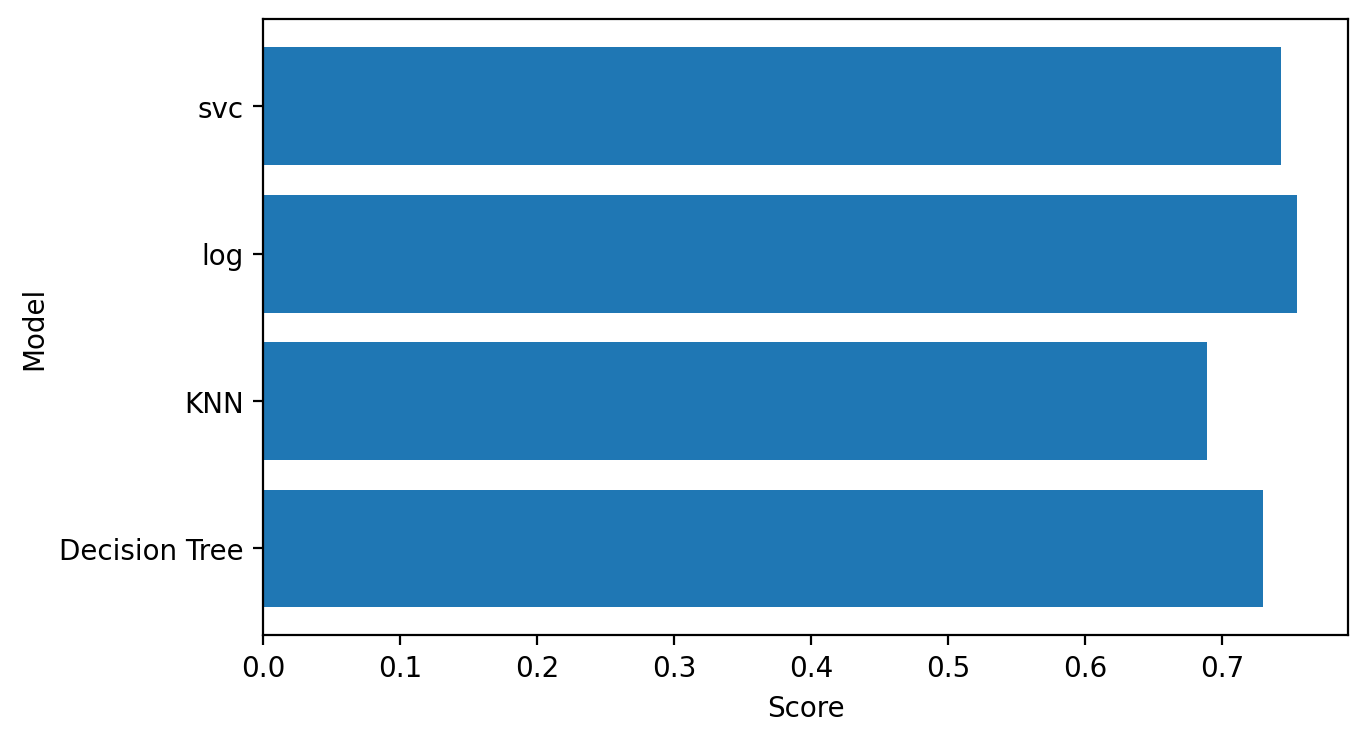

In [24]:
# 시각화
plt.figure(figsize=(7,4))
plt.barh(y=list(result), width=result.values(), data=result)
plt.ylabel('Model')
plt.xlabel('Score')
plt.show()

# 6. 실제 성능 확인

In [25]:
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.92      0.84       146
           1       0.79      0.54      0.64        85

    accuracy                           0.78       231
   macro avg       0.78      0.73      0.74       231
weighted avg       0.78      0.78      0.77       231

